# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


/opt/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [ ]:
# Load the dataset using Hugging Face Datasets library
from datasets import load_dataset

dataset = load_dataset("bjoern-doege/aesthetic-emotions-map")

In [81]:
# Display basic information about the dataset
print(dataset)
print(dataset["train"].features)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'style', 'motif', 'instance'],
        num_rows: 4720
    })
    validation: Dataset({
        features: ['image', 'label', 'style', 'motif', 'instance'],
        num_rows: 1024
    })
    test: Dataset({
        features: ['image', 'label', 'style', 'motif', 'instance'],
        num_rows: 1088
    })
})
{'image': Image(mode=None, decode=True), 'label': Value('large_string'), 'style': Value('int64'), 'motif': Value('large_string'), 'instance': Value('int64')}
{'image': <PIL.Image.Image image mode=RGB size=224x224 at 0x359636BD0>, 'label': 'sublime_activation', 'style': 1031505187, 'motif': 'antibiotics', 'instance': 0}


In [ ]:
# Convert the training split to a pandas DataFrame for easier analysis
train_df = dataset["train"].to_pandas()
train_df.head()

,image,label,style,motif,instance
0,"{'bytes': None, 'path': '/Users/bjornschmidt/....",sublime_activation,1031505187,antibiotics,0
1,"{'bytes': None, 'path': '/Users/bjornschmidt/....",sublime_activation,1031505187,antibiotics,1
2,"{'bytes': None, 'path': '/Users/bjornschmidt/....",sublime_activation,1031505187,antibiotics,2
3,"{'bytes': None, 'path': '/Users/bjornschmidt/....",sublime_activation,1031505187,antibiotics,3
4,"{'bytes': None, 'path': '/Users/bjornschmidt/....",lighthearted_humor,109966586,antibiotics,0


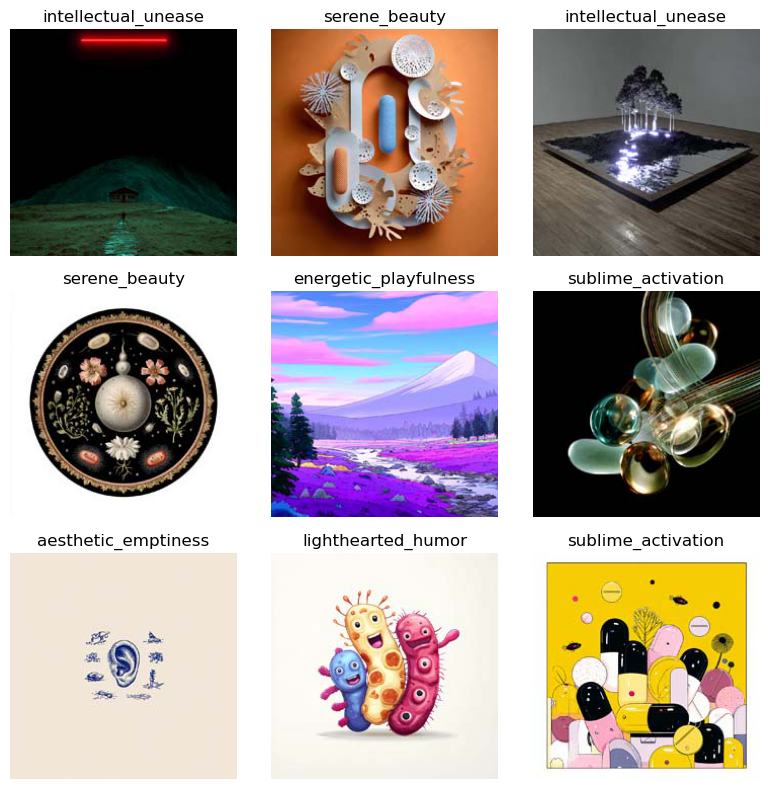

In [ ]:
# Visualize Random Samples
import matplotlib.pyplot as plt

samples = dataset["train"].shuffle(seed=42).select(range(9))

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, sample in zip(axes.flatten(), samples):
    ax.imshow(sample["image"])
    ax.set_title(sample["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


There are no missing values in the dataset, as all images and their corresponding metadata are complete and properly labeled.


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


In [ ]:
# Compute mean and std for normalization
import numpy as np

means = []
stds = []

for sample in dataset["train"]:
    img = np.array(sample["image"]).astype(np.float32) / 255.0

    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)

print(mean, std)

[0.5111493  0.48832294 0.46479088] [0.23357919 0.20812285 0.20773463]


In [48]:
# Check for unique labels, styles, motifs, and instances
for field in ["label", "style", "motif", "instance"]:
    for split in ["train", "validation", "test"]:
        print(f"Unique {field}s in {split} split: {len(set(dataset[split][field]))}")
    print()

Unique labels in train split: 8
Unique labels in validation split: 8
Unique labels in test split: 8

Unique styles in train split: 295
Unique styles in validation split: 64
Unique styles in test split: 68

Unique motifs in train split: 4
Unique motifs in validation split: 4
Unique motifs in test split: 4

Unique instances in train split: 4
Unique instances in validation split: 4
Unique instances in test split: 4



In [24]:
# Check for unique image sizes
for split in ["train", "validation", "test"]:
    sizes = [img["image"].size for img in dataset[split]]
    print(f"Unique image sizes in {split}: {set(sizes)}")

Unique image sizes in train: {(224, 224)}
Unique image sizes in validation: {(224, 224)}
Unique image sizes in test: {(224, 224)}


We assume that converting RGB images to HSV color space and computing statistics such as mean and standard deviation for hue, saturation, and value will provide useful insights into the color characteristics of the images.

In [ ]:
# Compute HSV statistics for each image and add to metadata
# HSV statistics can provide insights into the color distribution, saturation, and brightness of the images

def hsv_stats_from_image(image):
    arr = np.asarray(image.convert("HSV"), dtype=np.float32) / 255.0

    return pd.Series({
        "hue_mean": arr[:, :, 0].mean(),
        "hue_std": arr[:, :, 0].std(),
        "saturation_mean": arr[:, :, 1].mean(),
        "saturation_std": arr[:, :, 1].std(),
        "value_mean": arr[:, :, 2].mean(),
        "value_std": arr[:, :, 2].std(),
    })

# Concatenate metadata across splits and compute HSV features
metadata_parts = []

for split, split_dataset in dataset.items():
    split_metadata = split_dataset.remove_columns("image").to_pandas()
    split_metadata["set"] = split

    split_hsv_features = pd.DataFrame(
        [hsv_stats_from_image(sample["image"]) for sample in split_dataset]
    )

    metadata_parts.append(
        pd.concat([split_metadata.reset_index(drop=True), split_hsv_features], axis=1)
    )

metadata = pd.concat(metadata_parts, ignore_index=True)
metadata.head()


,label,style,motif,instance,set,hue_mean,hue_std,saturation_mean,saturation_std,value_mean,value_std
0,sublime_activation,1031505187,antibiotics,0,train,0.289886,0.251285,0.710426,0.284877,0.759316,0.265588
1,sublime_activation,1031505187,antibiotics,1,train,0.436738,0.224242,0.832090,0.252708,0.704216,0.159780
2,sublime_activation,1031505187,antibiotics,2,train,0.267076,0.238073,0.720264,0.268477,0.643485,0.245818
3,sublime_activation,1031505187,antibiotics,3,train,0.433691,0.208011,0.695770,0.193992,0.757654,0.131192
4,lighthearted_humor,109966586,antibiotics,0,train,0.385644,0.283643,0.564476,0.482921,0.958099,0.116190


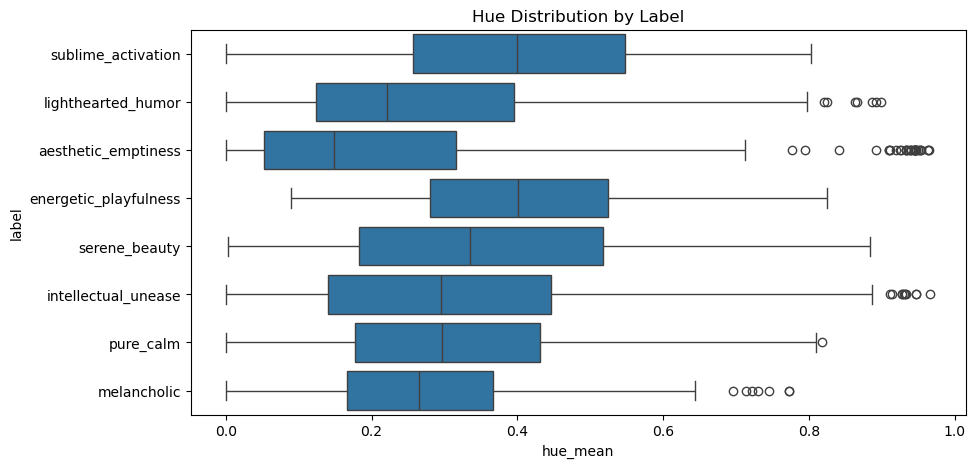

In [71]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=metadata, x="hue_mean", y="label")
plt.title("Hue Distribution by Label")
plt.show()


Hue values across all classes show a wide distribution, with some classes (lighthearted_humor and aesthetic_emptiness) having a lower mean hue compared to others. No single hue family dominates a class, which could make it challenging for a model to differentiate between classes based solely on hue.

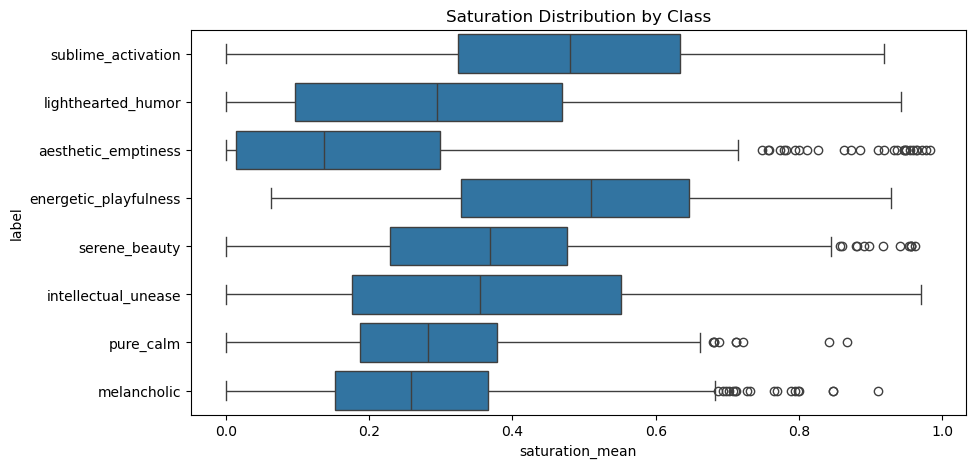

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=metadata, x="saturation_mean", y="label")
plt.title("Saturation Distribution by Class")
plt.show()


Saturation distributions are very similar to the distribution of hue with slight variations. Possibly a correlation between hue and saturation exists, which would be interesting to explore further. Not ideal for differentiation between classes.

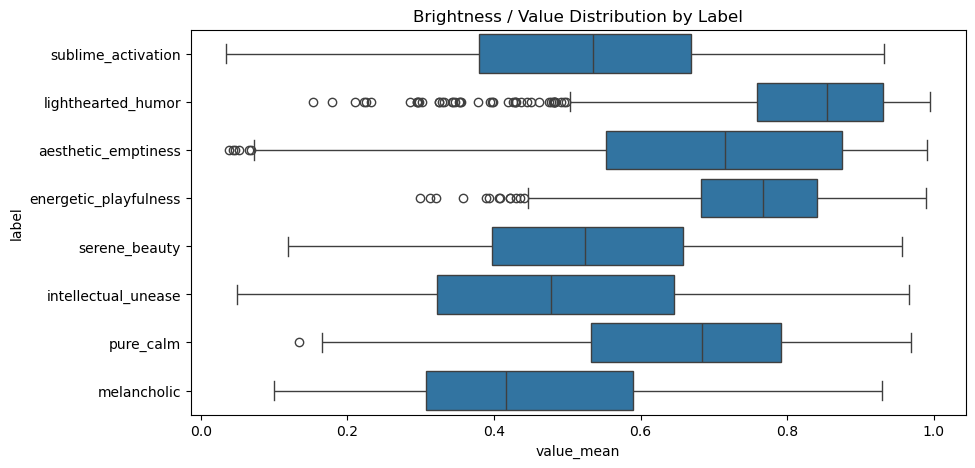

In [70]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=metadata, x="value_mean", y="label")
plt.title("Brightness / Value Distribution by Label")
plt.show()


The brighness (value) distributions span the entire range indicating a wide variety of brightness levels across the images with the exeption of the humorous classes (lighthearted_humor, energetic_playfulness).However, there are substantial differences in the mean brightness between classes. Allowing for differentiation, especially between the **high-brightness classes** (lighthearted_humor, energetic_playfulness, aesthetic_emptiness, pure_calm) and the **low-brightness classes** (sublime_activation, serene beauty, intellectual_challenge, melancholic).

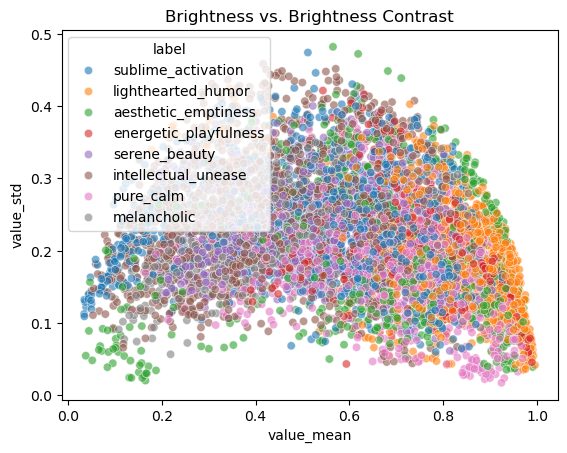

In [72]:
sns.scatterplot(
    data=metadata,
    x="value_mean",
    y="value_std",
    hue="label",
    alpha=0.6
)

plt.title("Brightness vs. Brightness Contrast")
plt.show()


This plot shows the relationship between average brightness and brightness variability for individual images. The "lighthearted_humor" class (orange) seems to dominate the rightmost region indicating higher brightness and lower contrast, while some images of the "sublime_activation" class (blue) are more concentrated in the leftmost region indicating lower brightness and lower contrast. However, there is a significant overlap between the classes, suggesting that brightness and contrast alone may not be sufficient for clear differentiation between all classes.

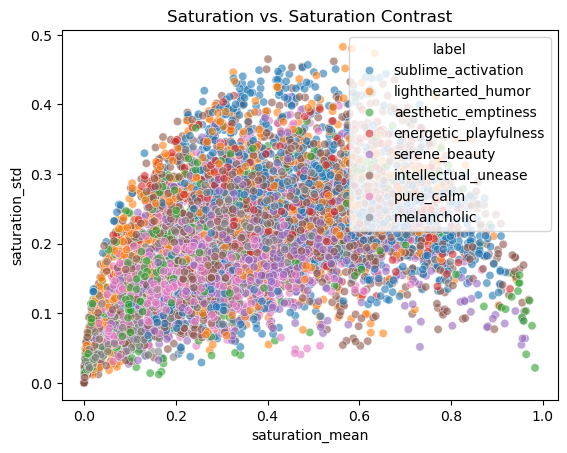

In [73]:
sns.scatterplot(
    data=metadata,
    x="saturation_mean",
    y="saturation_std",
    hue="label",
    alpha=0.6
)

plt.title("Saturation vs. Saturation Contrast")
plt.show()


Similar to the previous plot, this plot shows the relationship between average saturation and saturation variability for individual images. Upon visual inspection, there are some regions where classes may be distinguishable, but no clear separation between classes is visible, indicating that saturation and its variability may not be strong differentiating features for the classes in this dataset.

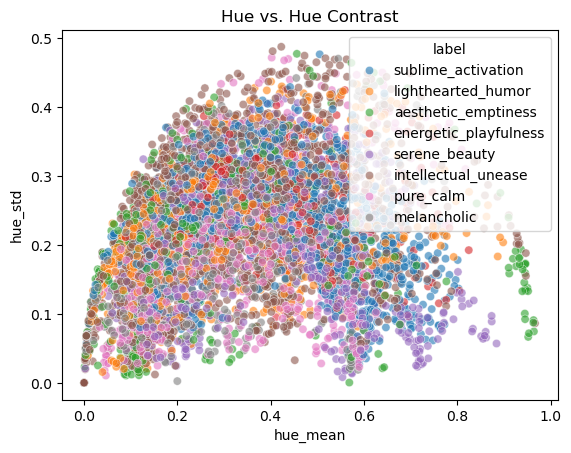

In [100]:
sns.scatterplot(
    data=metadata,
    x="hue_mean",
    y="hue_std",
    hue="label",
    alpha=0.6
)

plt.title("Hue vs. Hue Contrast")
plt.show()


Similarly, the plot of hue mean vs. hue standard deviation shows no clear separation between classes, suggesting that hue and its variability may also not be strong differentiating features for the classes in this dataset.

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


In [ ]:
min_label_count = metadata["label"].value_counts().min()
max_label_count = metadata["label"].value_counts().max()

print(f"Minimum images per class: {min_label_count}")
print(f"Maximum images per class: {max_label_count}")

Minimum images per class: 368
Maximum images per class: 1568


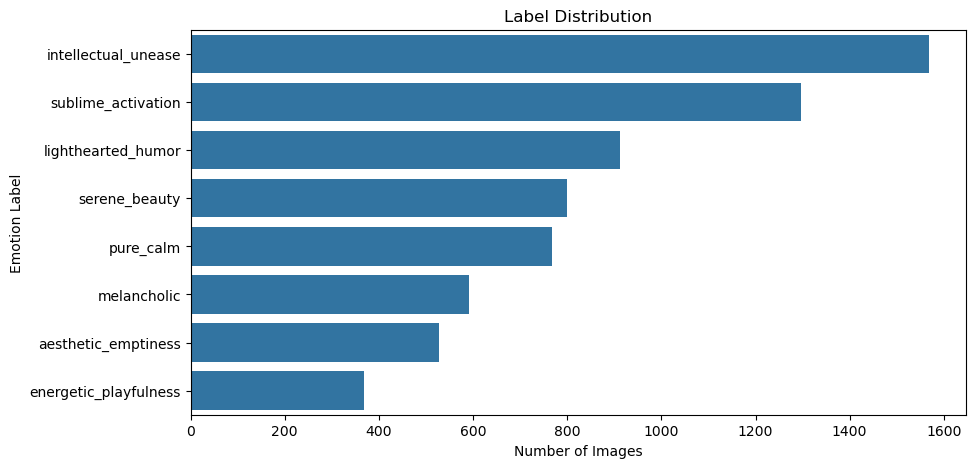

In [ ]:
# Example: Checking for class imbalance in a classification problem
# sns.countplot(x='target_variable', data=df)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(data=metadata, y="label", order=metadata["label"].value_counts().index)
plt.title("Label Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Emotion Label")
plt.show()


The distribution of images across the 8 classes is not balanced and ranges from 368 to 1568 images per class. This class imbalance could potentially bias the model towards the classes with more samples, leading to poorer performance on underrepresented classes. It may be necessary to consider techniques such as resampling, data augmentation, or using class weights during model training to mitigate this bias.

In [93]:
# The distribution of classes across the different splits

label_split = pd.crosstab(metadata["label"], metadata["set"])
label_split


set,test,train,validation
label,,,
aesthetic_emptiness,80,368,80
energetic_playfulness,64,256,48
intellectual_unease,240,1088,240
lighthearted_humor,144,624,144
melancholic,96,400,96
pure_calm,128,528,112
serene_beauty,128,560,112
sublime_activation,208,896,192


In [ ]:
# Check for overlap in styles across splits
train_styles = set(metadata[metadata["set"] == "train"]["style"])
val_styles = set(metadata[metadata["set"] == "validation"]["style"])
test_styles = set(metadata[metadata["set"] == "test"]["style"])

print("Train/val overlap:", len(train_styles & val_styles))
print("Train/test overlap:", len(train_styles & test_styles))
print("Val/test overlap:", len(val_styles & test_styles))


Train/val overlap: 0
Train/test overlap: 0
Val/test overlap: 0


## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


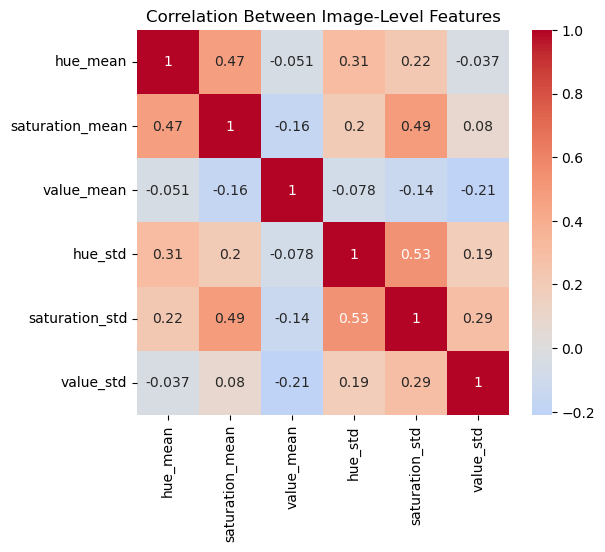

In [101]:
derived_features = metadata[
    ["hue_mean", "saturation_mean", "value_mean", "hue_std", "saturation_std", "value_std"]
]

plt.figure(figsize=(6, 5))
sns.heatmap(derived_features.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Image-Level Features")
plt.show()


This is no relationship between hue and brightness which means that the features carry different information so they may each contribute uniquely in a CNN.

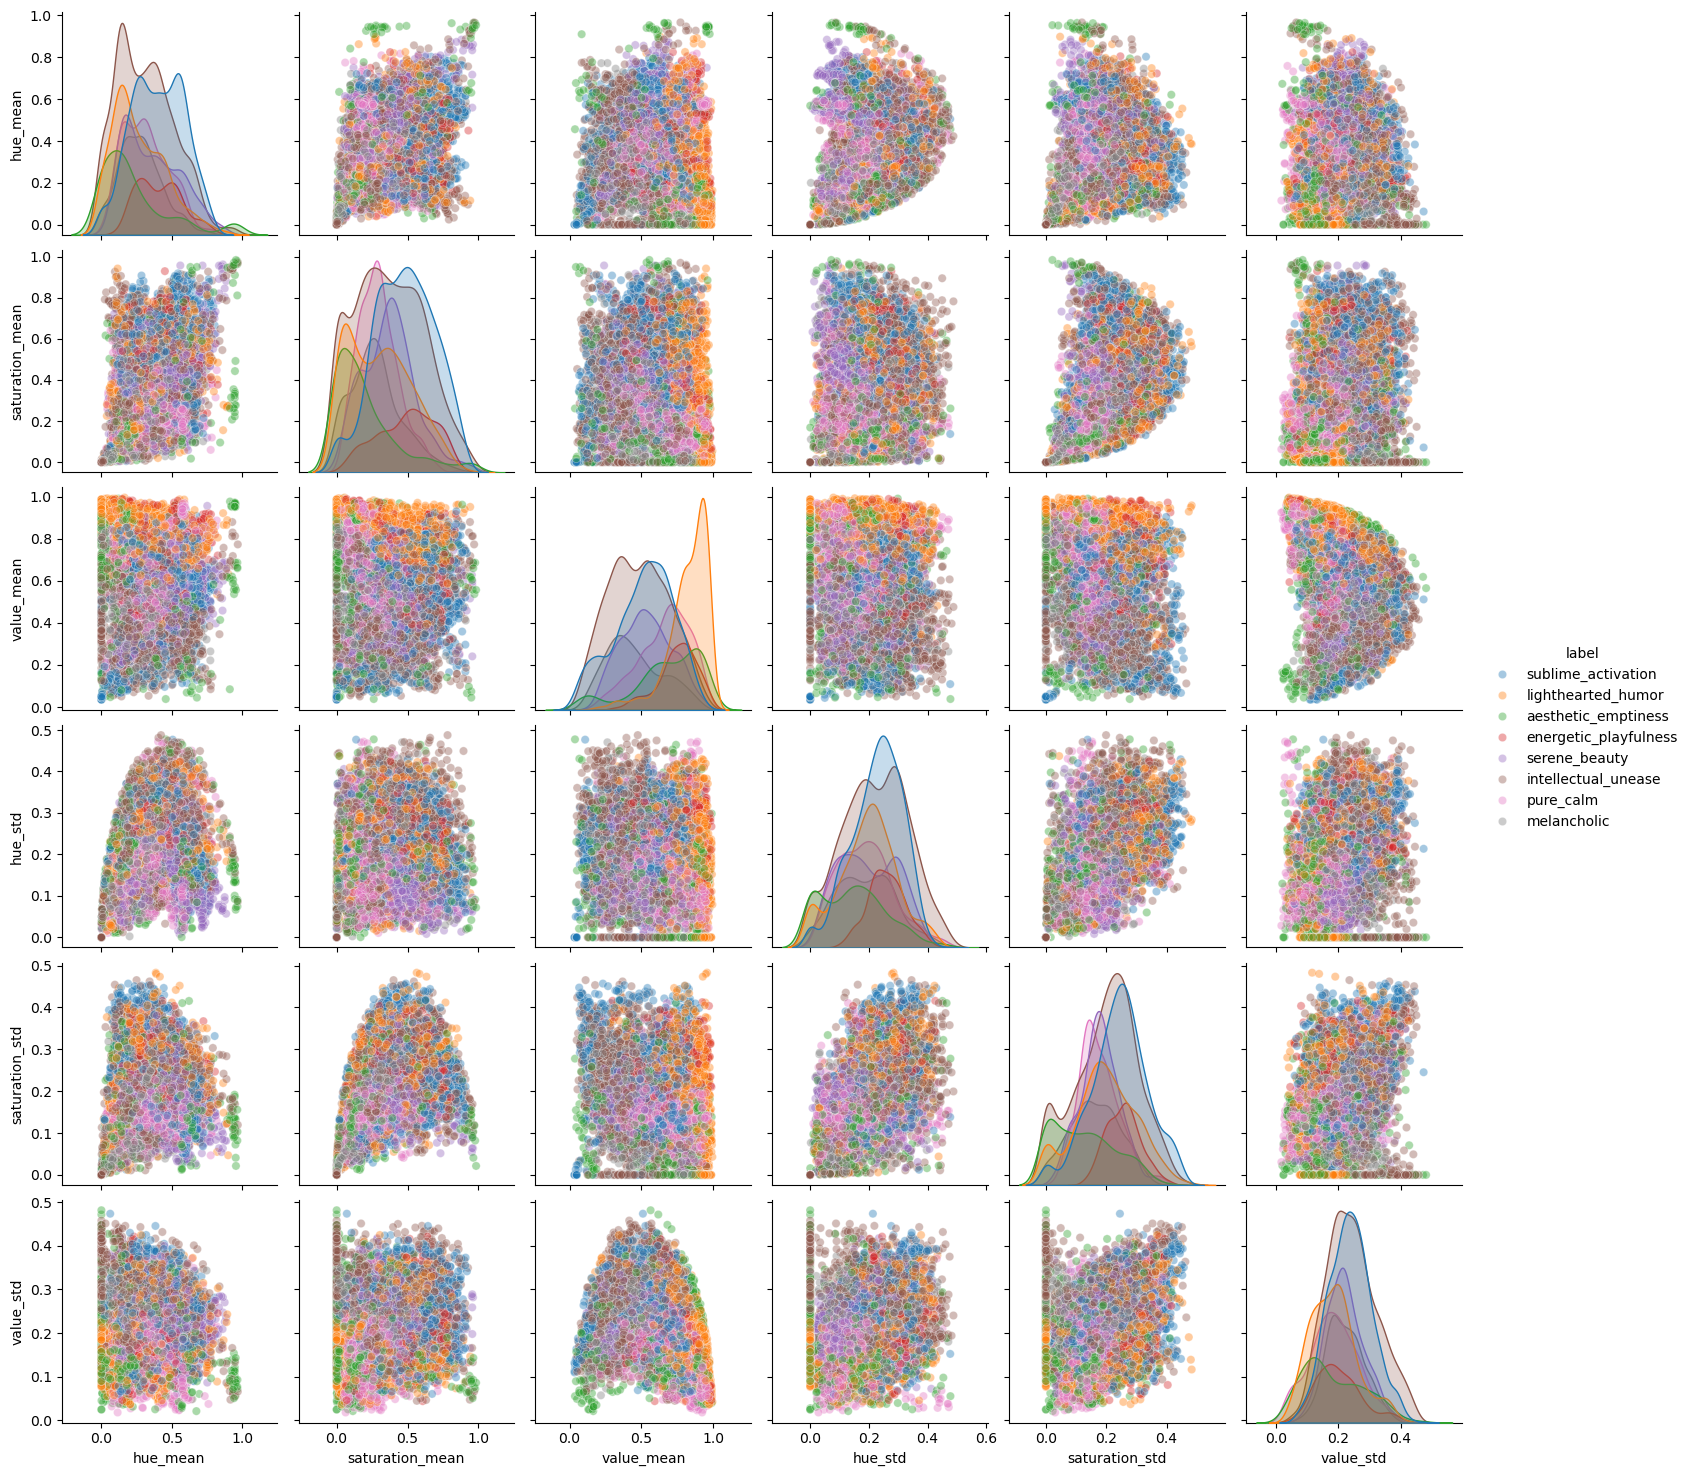

In [102]:
sns.pairplot(
    metadata,
    vars=["hue_mean", "saturation_mean", "value_mean", "hue_std", "saturation_std", "value_std"],
    hue="label",
    plot_kws={"alpha": 0.4}
)
plt.show()


There seems to be great overlap between classes but some distinctions are visible upon closer inspection. This could be explained by the heterogeneity of the styles since different stylistic features may evoke the same emotional response making a classification challenging but worth pursuing.